# CIL + FL Task/Round Plots

In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import re
from pathlib import Path


In [11]:
log_files = [
    #"results_cil/FedAvg_finetune_10client_label_skew_0.1_5.0.log", #baseline
    #"results_cil/FedAvg_lwf_10client_label_skew_0.1_5.0_alpha0.99_temp2.0.log",
    #"results_cil/FedAvg_ewc_10client_label_skew_0.1_5.0_lambda10.0.log",
    #"results_cil/FedAvg_mas_10client_label_skew_0.1_5.0_lambda20.0.log",
    #"results_cil/FedAvg_pass_10client_label_skew_0.1_5.0_lam10.0_g300.0_ps50.log",
    # replay + dynamic
    #"results_cil/FedAvg_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0.log",
    #"results_cil/FedAvg_foster_10client_label_skew_0.1_5.0_mem500_b1_0.97_b2_0.97_okd1.0.log",
    #"results_cil/FedAvg_icarl_10client_label_skew_0.1_5.0_mem200_bce0.log",
    #"results_cil/FedAvg_foster_10client_label_skew_0.1_5.0_mem500_b1_0.97_b2_0.97_okd1.0.log",
    #"results_cil/FedAvg_icarl_10client_label_skew_0.1_5.0_mem500_bce0.log",
    #"results_cil/FedAvg_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0_val0.4.log",
    #"results_cil/FedAvg_foster_10client_label_skew_0.1_5.0_mem500_b1_0.97_b2_0.97_okd1.0.log",
    #"results_cil/FedAvg_glfc_10client_label_skew_0.1_5.0_mem500_enc50.log",
    #"results_cil/FedAvg_cbkd_10client_label_skew_0.1_5.0_lam100.0_a1000.0_b10.0.log",
]

# side-by-side
# log_files = [
#     # EWC
#     "results_cil/FedAvg_ewc_10client_label_skew_0.1_5.0_lambda10.0.log",
#     "results_cil/FedSSD_ewc_10client_label_skew_0.1_5.0_lambda10.0_ssd1.0.log",
#     # iCaRL
#     "results_cil/FedAvg_icarl_10client_label_skew_0.1_5.0_mem500_bce0.log",
#     "results_cil/FedSSD_icarl_10client_label_skew_0.1_5.0_mem500_bce0_ssd1.0.log",
#     # BiC
#     "results_cil/FedAvg_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0_val0.4.log",
#     "results_cil/FedSSD_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0_val0.4_ssd1.0.log",
# ]

# final thesis
log_files = [
    "results_cil/FedAvg_finetune_100client_label_skew_0.1_5.0_gru.log",
    "results_cil/FedAvg_lwf_100client_label_skew_0.1_5.0_gru_alpha0.99_temp2.0.log",
    "results_cil/FedAvg_ewc_100client_label_skew_0.1_5.0_gru_lambda1000.0.log",
    "results_cil/FedAvg_mas_100client_label_skew_0.1_5.0_gru_lambda200.0.log",
    "results_cil/FedAvg_icarl_100client_label_skew_0.1_5.0_gru_mem1.0_bce1.log",
    "results_cil/FedAvg_bic_100client_label_skew_0.1_5.0_gru_mem1.0_alpha0.5_temp2.0_val0.4.log",
    "results_cil/FedAvg_feat_100client_label_skew_0.1_5.0_gru_mem200_lam0.1_rho0.9_temp0.5_approx.log",
    "results_cil/FedAvg_pass_100client_label_skew_0.1_5.0_gru_lam10.0_g10.0_ps200.log",
    "results_cil/FedAvg_foster_100client_label_skew_0.1_5.0_gru_mem1.0_b1_0.97_b2_0.97_okd1.0_ce50.log",
    "results_cil/FedAvg_cbkd_100client_label_skew_0.1_5.0_gru_lam10.0_a10.0_b10.0_ps200.log",
    #"results_cil/FedAvg_ours_100client_label_skew_0.1_5.0_gru_mem1.0_lam0.1_rho0.9_temp0.5_plam1.0_ekd2_ekdl1.0_kg10.0_rel5.0_enc0.1_meanlogits.log",
    #"results_cil/FedAvg_ours2_100client_label_skew_0.1_5.0_gru_mem1.0_kg1.0_eva0.95_blom0.9 copy.log",
    "results_cil/FedAvg_ours3_100client_label_skew_0.1_5.0_gru_mem1.0_kg1.0_gated_eva0.95_blom0.9_synth.log",
    "results_cil/FedAvg_ours3_100client_label_skew_0.1_5.0_gru_mixed_mem1.0_kg1.0_gated_eva0.95_blom0.3.log"
]



In [13]:
canon_name = [
    "FedAvg",
    "FedAvg-LwF",
    "FedAvg-EWC",
    "FedAvg-MAS",
    "FedAvg-iCaRL",
    "FedAvg-BiC",
    "FEAT",
    "FedAvg-PASS",
    "FedAvg-FOSTER",
    "FedAvg-CBKD EFCIL",
    "Đề xuất (single)",
    "Đề xuất (multiple)"
    # add more names here in the same order as log_files
]


In [9]:
ansi_re = re.compile(r"\x1b\[[0-9;]*m")
timestamp_re = re.compile(r"^\[\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}\]\s*")
task_re = re.compile(r"^TASK\s+(\d+):")
task_eval_re = re.compile(
    r"^EVAL\s+\|\s+T(\d+)\s+\|\s+R(\d+)\s+\|\s+Task(\d+)\s+\|\s+"
    r"Acc=([\d.]+)\s+\|\s+Loss=(nan|[\d.]+)\s+\|\s+F1_mac=([\d.]+)\s+\|\s+F1_mic=([\d.]+)"
)
merged_eval_re = re.compile(
    r"^EVAL\s+\|\s+T(\d+)\s+\|\s+R(\d+)\s+\|\s+"
    r"Acc=([\d.]+)\s+\|\s+Loss=(nan|[\d.]+)\s+\|\s+F1_mac=([\d.]+)\s+\|\s+F1_mic=([\d.]+)"
    r"(?:\s+\|\s+F1_w=([\d.]+))?"
)
final_re = re.compile(
    r"^FINAL\s+\|\s+all\s+\d+\s+classes\s+\|\s+"
    r"Acc=([\d.]+)\s+\|\s+Loss=(nan|[\d.]+)\s+\|\s+F1_mac=([\d.]+)\s+\|\s+F1_mic=([\d.]+)"
)
old_final_re = re.compile(r"Final test.*Acc=([\d.]+)\s*\|\s*Loss=([\d.]+)")
per_task_prefix_re = re.compile(r"^(EVAL|FINAL)\s+\|\s+(?:T(\d+)\s+\|\s+R(\d+)|all\s+\d+\s+classes)\s+\|\s+per-task\s+\|\s+(.+)$")
per_task_item_re = re.compile(r"T(\d+):acc=([\d.]+),f1=([\d.]+),n=([\d.]+)")


def _metric(acc, loss=np.nan, f1_macro=np.nan, f1_micro=np.nan, f1_weighted=np.nan):
    if isinstance(loss, str) and loss == "nan":
        loss = np.nan
    return {"acc": float(acc), "loss": float(loss), "f1_macro": float(f1_macro), "f1_micro": float(f1_micro), "f1_weighted": float(f1_weighted)}


def parse_cil_log(path):
    lines = Path(path).read_text().splitlines()
    tasks = defaultdict(lambda: defaultdict(dict))
    merged = defaultdict(dict)
    task_max_round = defaultdict(int)
    pending_merged_loss = {}
    for raw in lines:
        line = ansi_re.sub("", raw).strip()
        line = timestamp_re.sub("", line)
        m = task_eval_re.match(line)
        if m:
            train_task = int(m.group(1))
            r = int(m.group(2))
            eval_task = int(m.group(3))
            tasks[train_task][r][eval_task] = _metric(m.group(4), m.group(5), m.group(6), m.group(7))
            task_max_round[train_task] = max(task_max_round[train_task], r)
            continue
        m = merged_eval_re.match(line)
        if m:
            train_task = int(m.group(1))
            r = int(m.group(2))
            f1_w = float(m.group(7)) if m.group(7) else np.nan
            merged[train_task][r] = _metric(m.group(3), m.group(4), m.group(5), m.group(6), f1_w)
            pending_merged_loss[(train_task, r)] = np.nan if m.group(4) == "nan" else float(m.group(4))
            task_max_round[train_task] = max(task_max_round[train_task], r)
            continue
        m = per_task_prefix_re.match(line)
        if m and m.group(1) == "EVAL":
            train_task = int(m.group(2))
            r = int(m.group(3))
            loss = pending_merged_loss.get((train_task, r), np.nan)
            for item in per_task_item_re.finditer(m.group(4)):
                eval_task = int(item.group(1))
                tasks[train_task][r][eval_task] = _metric(item.group(2), loss, item.group(3), np.nan)
            task_max_round[train_task] = max(task_max_round[train_task], r)
    task_ids = sorted(set(tasks) | set(merged) | set(task_max_round))
    offsets = {}
    offset = 0
    for t in task_ids:
        offsets[t] = offset
        offset += task_max_round[t]
    return tasks, merged, task_max_round, offsets


def parse_final_metrics(path):
    lines = Path(path).read_text().splitlines()
    for raw in reversed(lines):
        line = ansi_re.sub("", raw).strip()
        line = timestamp_re.sub("", line)
        m = final_re.search(line)
        if m:
            return _metric(m.group(1), m.group(2), m.group(3), m.group(4))
        m = old_final_re.search(line)
        if m:
            return _metric(m.group(1), m.group(2))
    return None


def parse_final_task_metrics(path):
    lines = Path(path).read_text().splitlines()
    for raw in reversed(lines):
        line = timestamp_re.sub("", line)
        m = per_task_prefix_re.match(line)
        if m and m.group(1) == "FINAL":
            return {int(item.group(1)): _metric(item.group(2), np.nan, item.group(3), np.nan)
                    for item in per_task_item_re.finditer(m.group(4))}
    return {}


def parse_final_acc(path):
    metrics = parse_final_metrics(path)
    if metrics is None:
        return None, None
    return metrics["acc"], metrics["loss"]


def build_per_task_series(tasks, task_max_round, offsets, metric="acc"):
    series = defaultdict(lambda: {"x": [], "y": []})
    for task_id in sorted(tasks.keys()):
        for r in range(1, task_max_round[task_id] + 1):
            evals = tasks[task_id].get(r, {})
            for eval_task, vals in evals.items():
                abs_r = offsets[task_id] + r
                series[eval_task]["x"].append(abs_r)
                series[eval_task]["y"].append(vals[metric])
    return series


def build_merged_series(merged, task_max_round, offsets, metric="acc"):
    xs, ys = [], []
    for task_id in sorted(task_max_round):
        for r in range(1, task_max_round[task_id] + 1):
            vals = merged.get(task_id, {}).get(r)
            if vals:
                xs.append(offsets[task_id] + r)
                ys.append(vals[metric])
    return xs, ys


def build_old_new_series(tasks, task_max_round, offsets):
    xs = []
    new_acc = []
    old_acc = []
    new_loss = []
    old_loss = []
    for task_id in sorted(tasks.keys()):
        for r in range(1, task_max_round[task_id] + 1):
            evals = tasks[task_id].get(r, {})
            abs_r = offsets[task_id] + r
            xs.append(abs_r)
            cur = evals.get(task_id)
            new_acc.append(cur["acc"] if cur else np.nan)
            new_loss.append(cur["loss"] if cur else np.nan)
            old_vals = [v for k, v in evals.items() if k < task_id]
            if old_vals:
                old_acc.append(np.mean([v["acc"] for v in old_vals]))
                old_loss.append(np.mean([v["loss"] for v in old_vals]))
            else:
                old_acc.append(np.nan)
                old_loss.append(np.nan)
    return xs, new_acc, old_acc, new_loss, old_loss


def task_spans(task_max_round, offsets):
    spans = []
    for t in sorted(task_max_round.keys()):
        start = offsets[t] + 1
        end = offsets[t] + task_max_round[t]
        spans.append((t, start, end))
    return spans


mem_re = re.compile(r"mem([\d.]+)")
alpha_re = re.compile(r"alpha([\d.]+)")
lambda_re = re.compile(r"(?:lambda|lam)([\d.]+)")
val_re = re.compile(r"val([\d.]+)")


def parse_name(path):
    name = Path(path).stem
    parts = name.split("_")
    fl = parts[0] if parts else ""
    cil = parts[1] if len(parts) > 1 else ""
    client = next((p for p in parts if p.endswith("client")), "")
    partition = "label skew" if "label_skew" in name else "iid" if "iid" in parts else ""
    lam_m = lambda_re.search(name)
    mem_m = mem_re.search(name)
    alpha_m = alpha_re.search(name)
    val_m = val_re.search(name)
    extras = []
    if lam_m:
        extras.append(f"lambda={lam_m.group(1)}")
    if mem_m:
        extras.append(f"mem={mem_m.group(1)}")
    if alpha_m:
        extras.append(f"alpha={alpha_m.group(1)}")
    if val_m:
        extras.append(f"val={val_m.group(1)}")
    tag = f" ({', '.join(extras)})" if extras else ""
    #return f"{fl} {cil}{tag} - {client} {partition}"
    return f"{cil}"

## Metrics over rounds

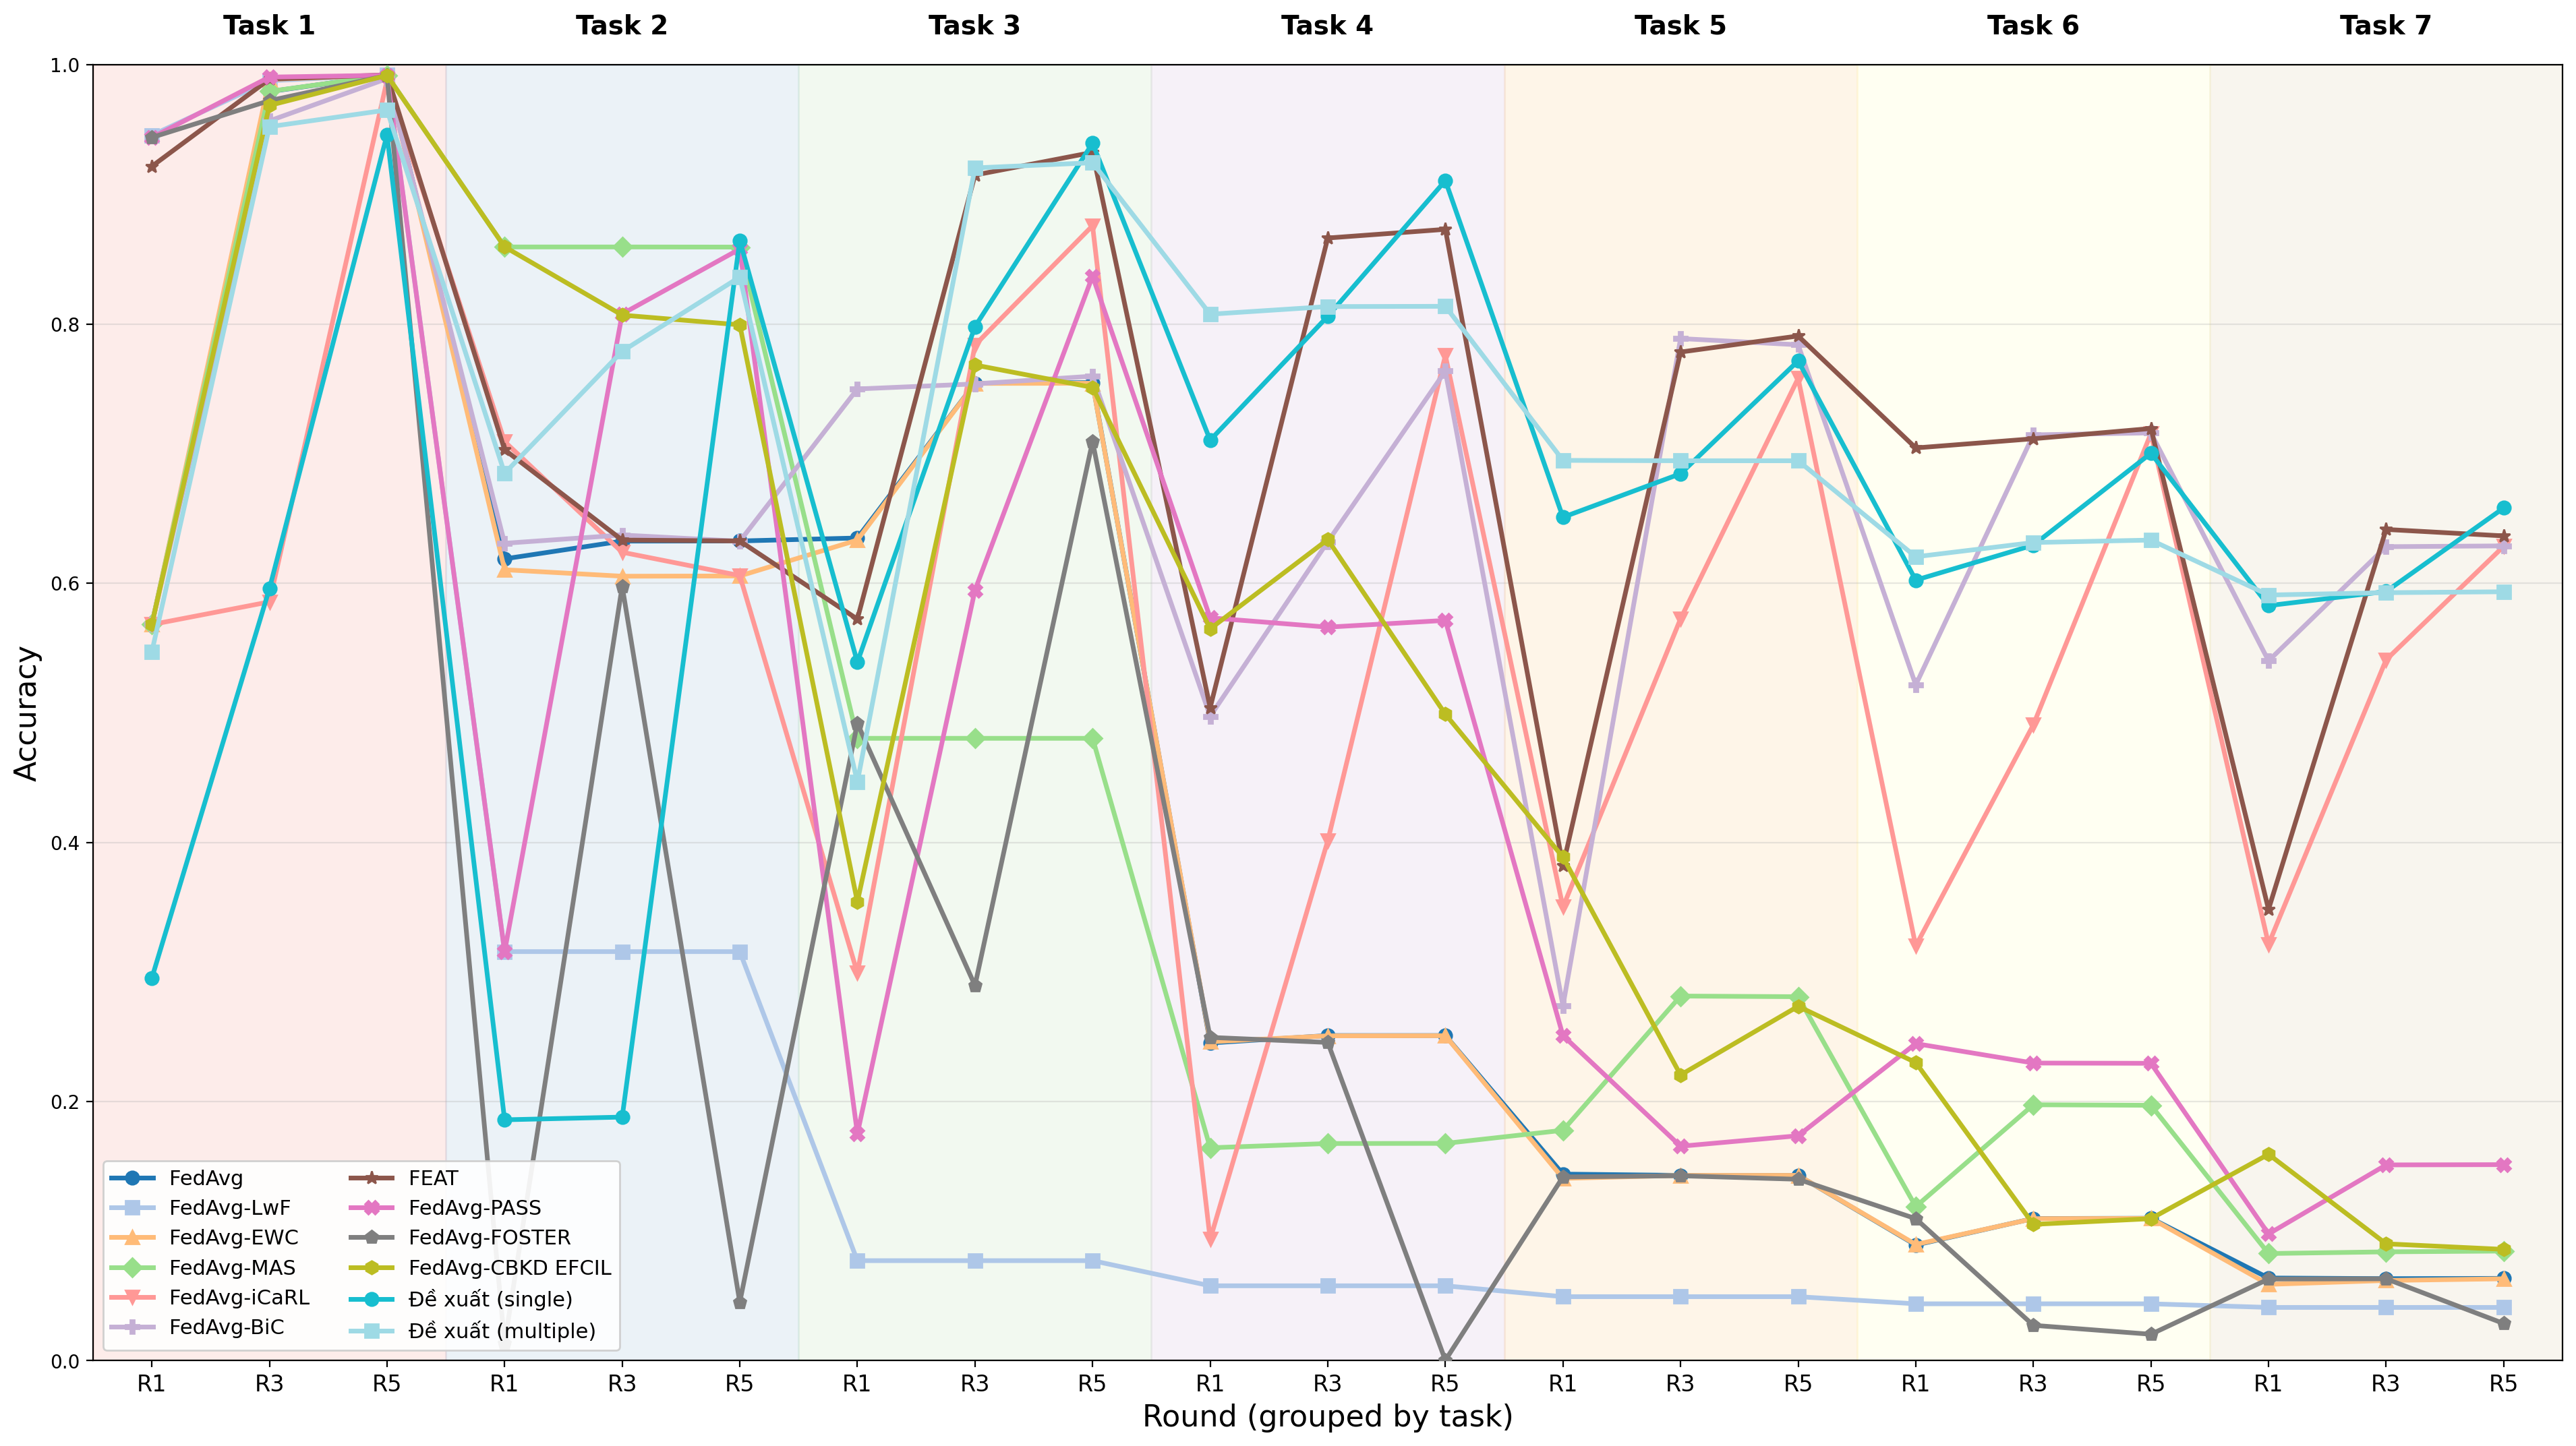

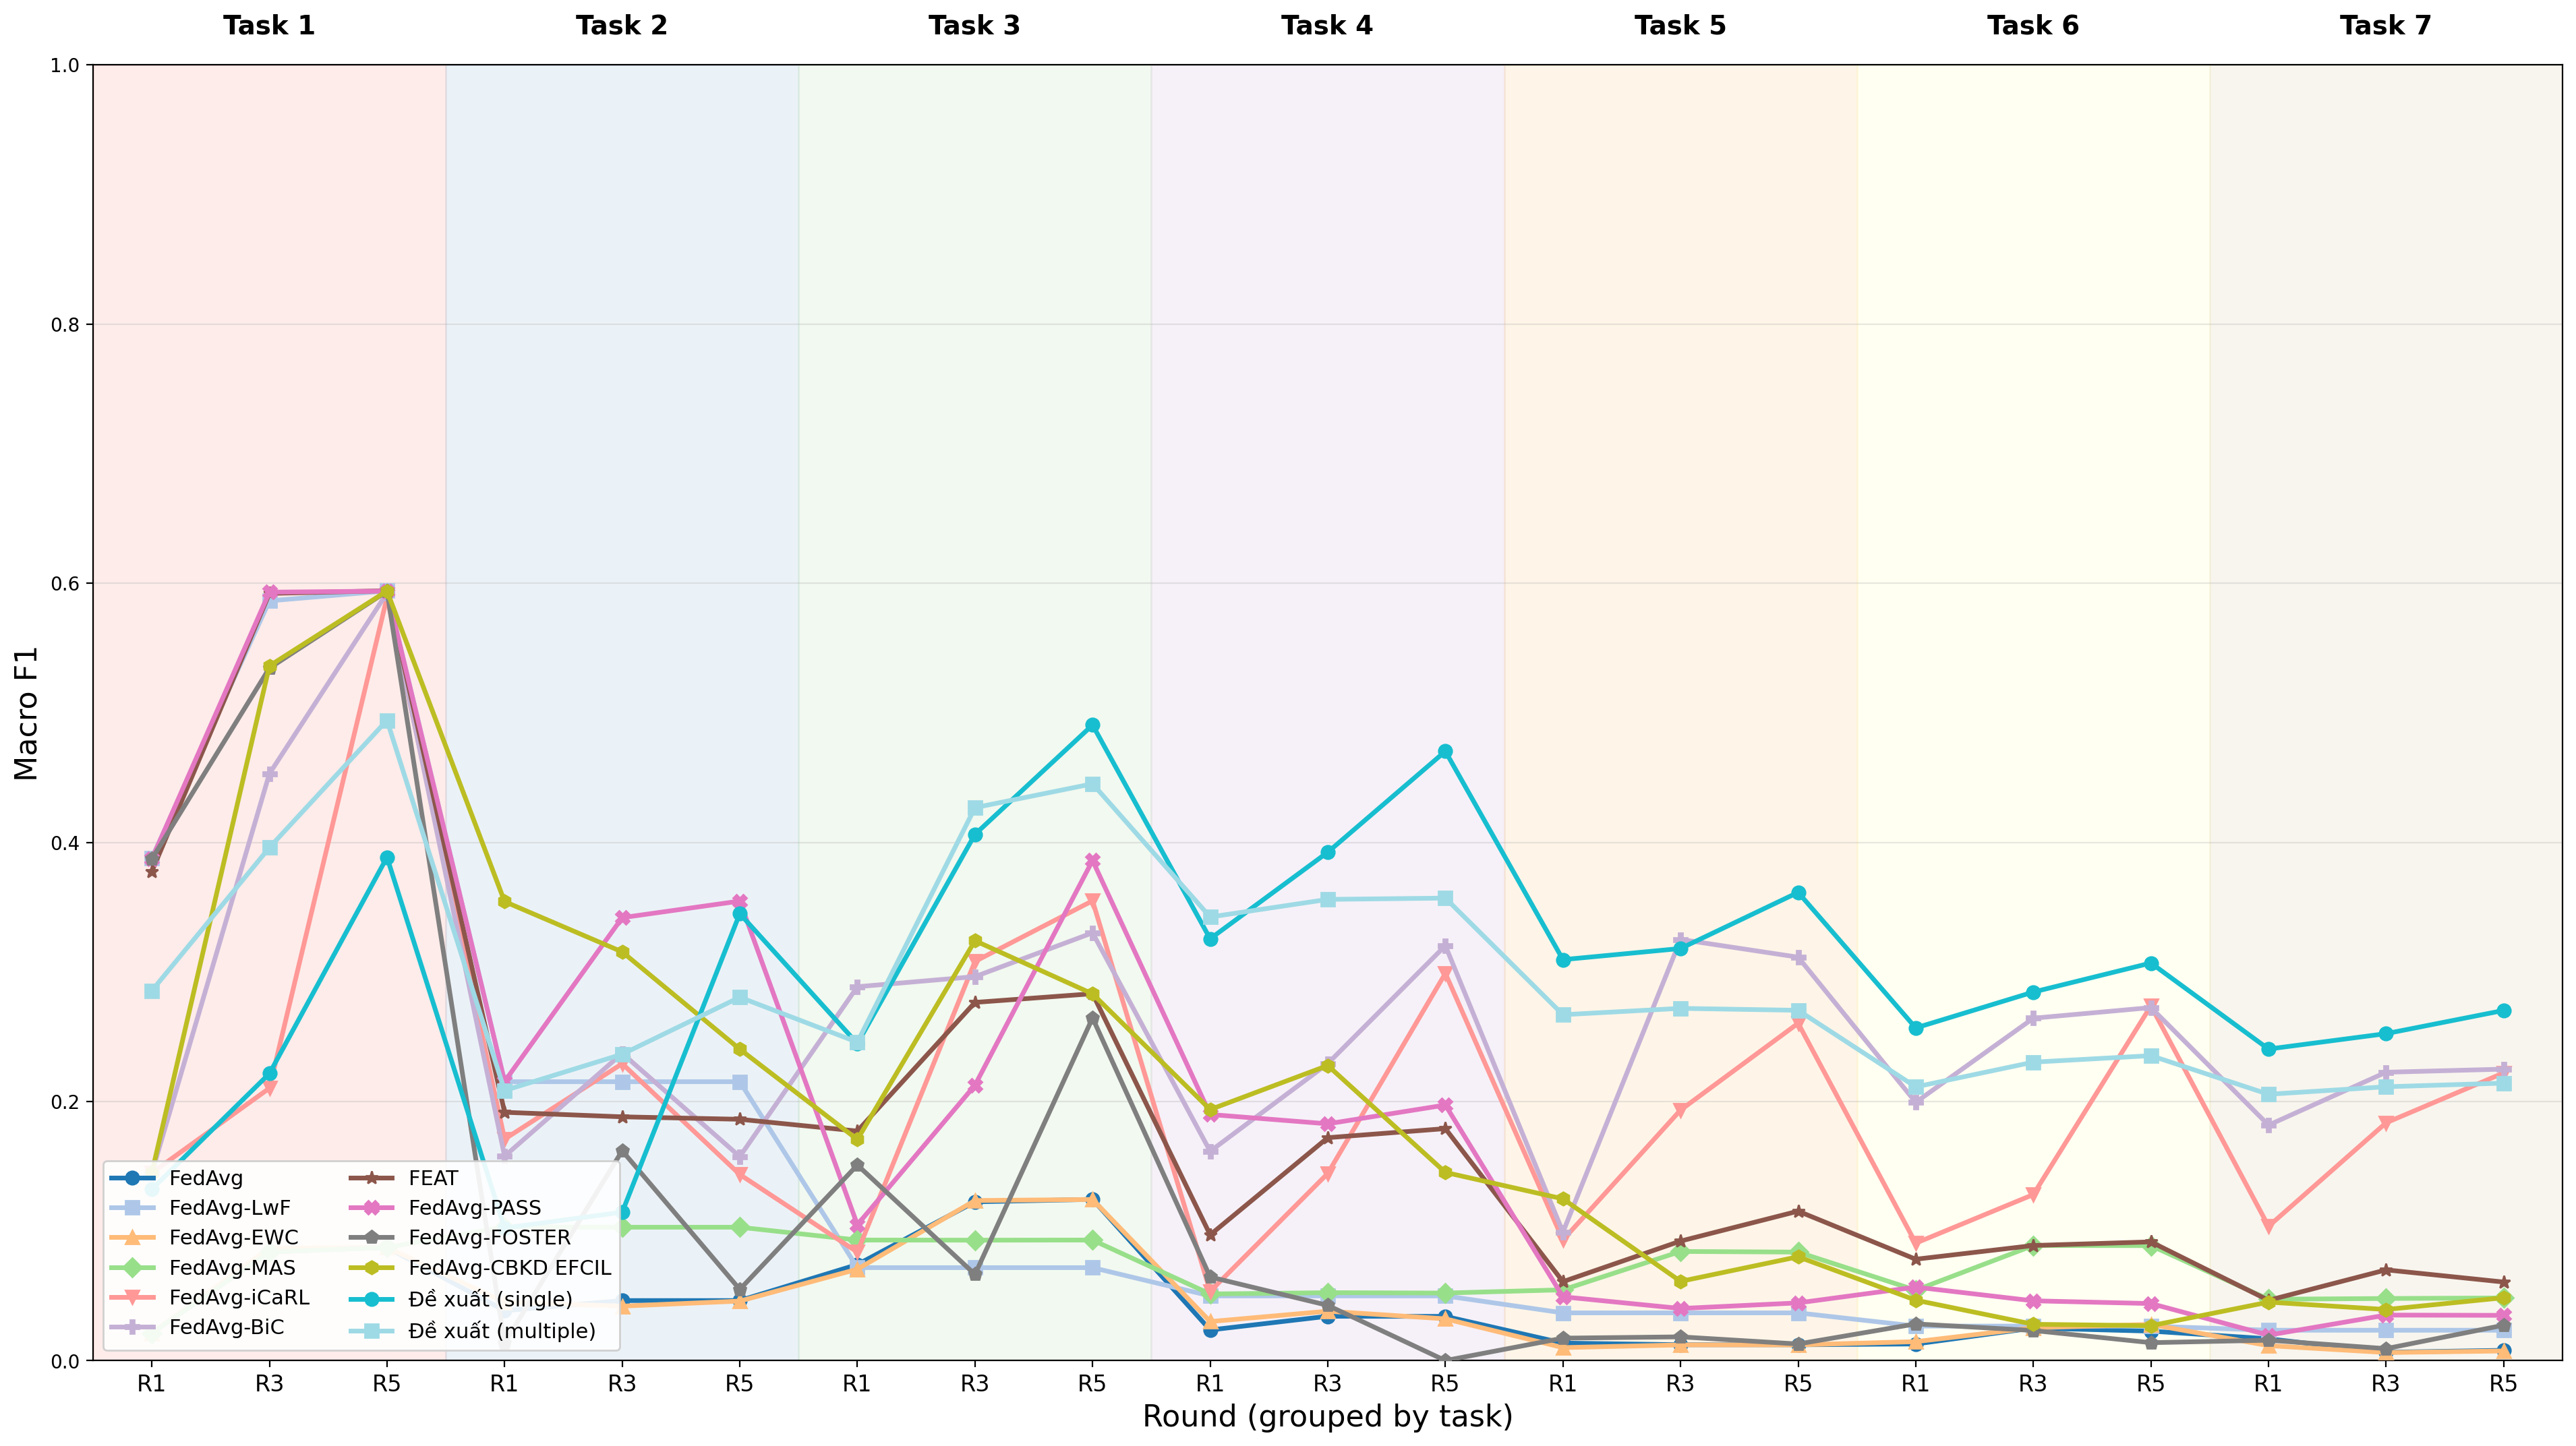

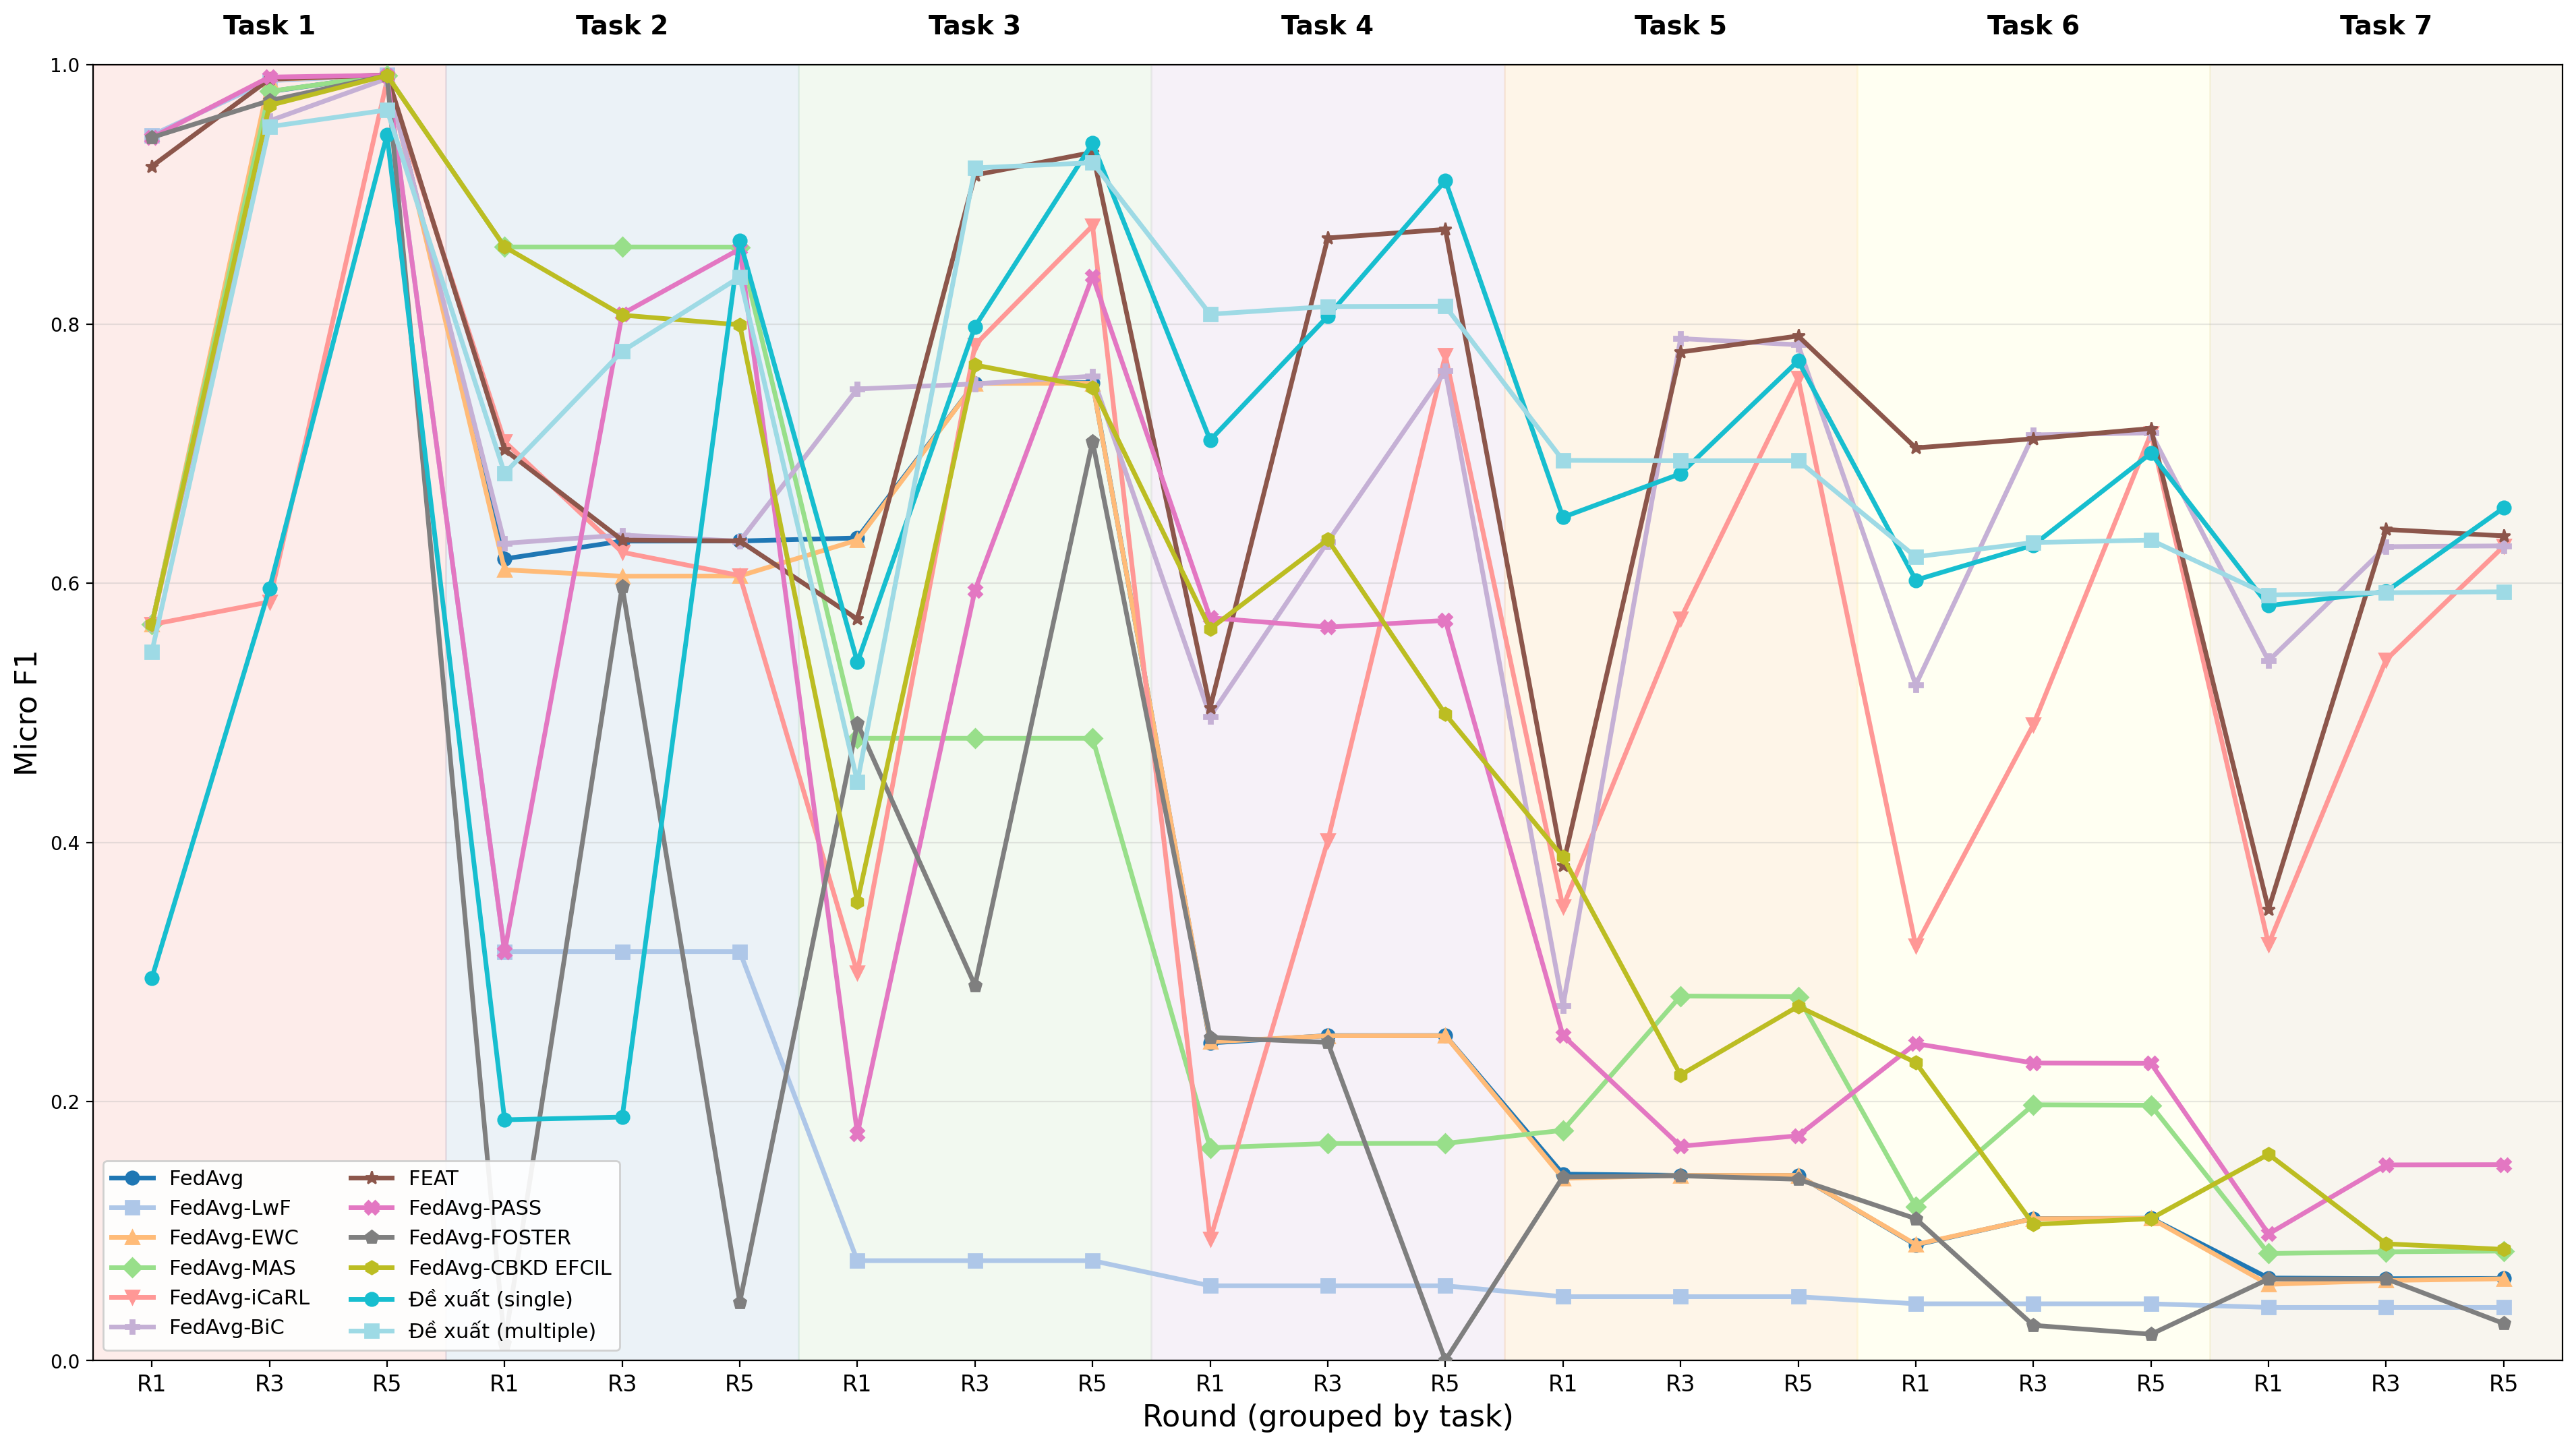

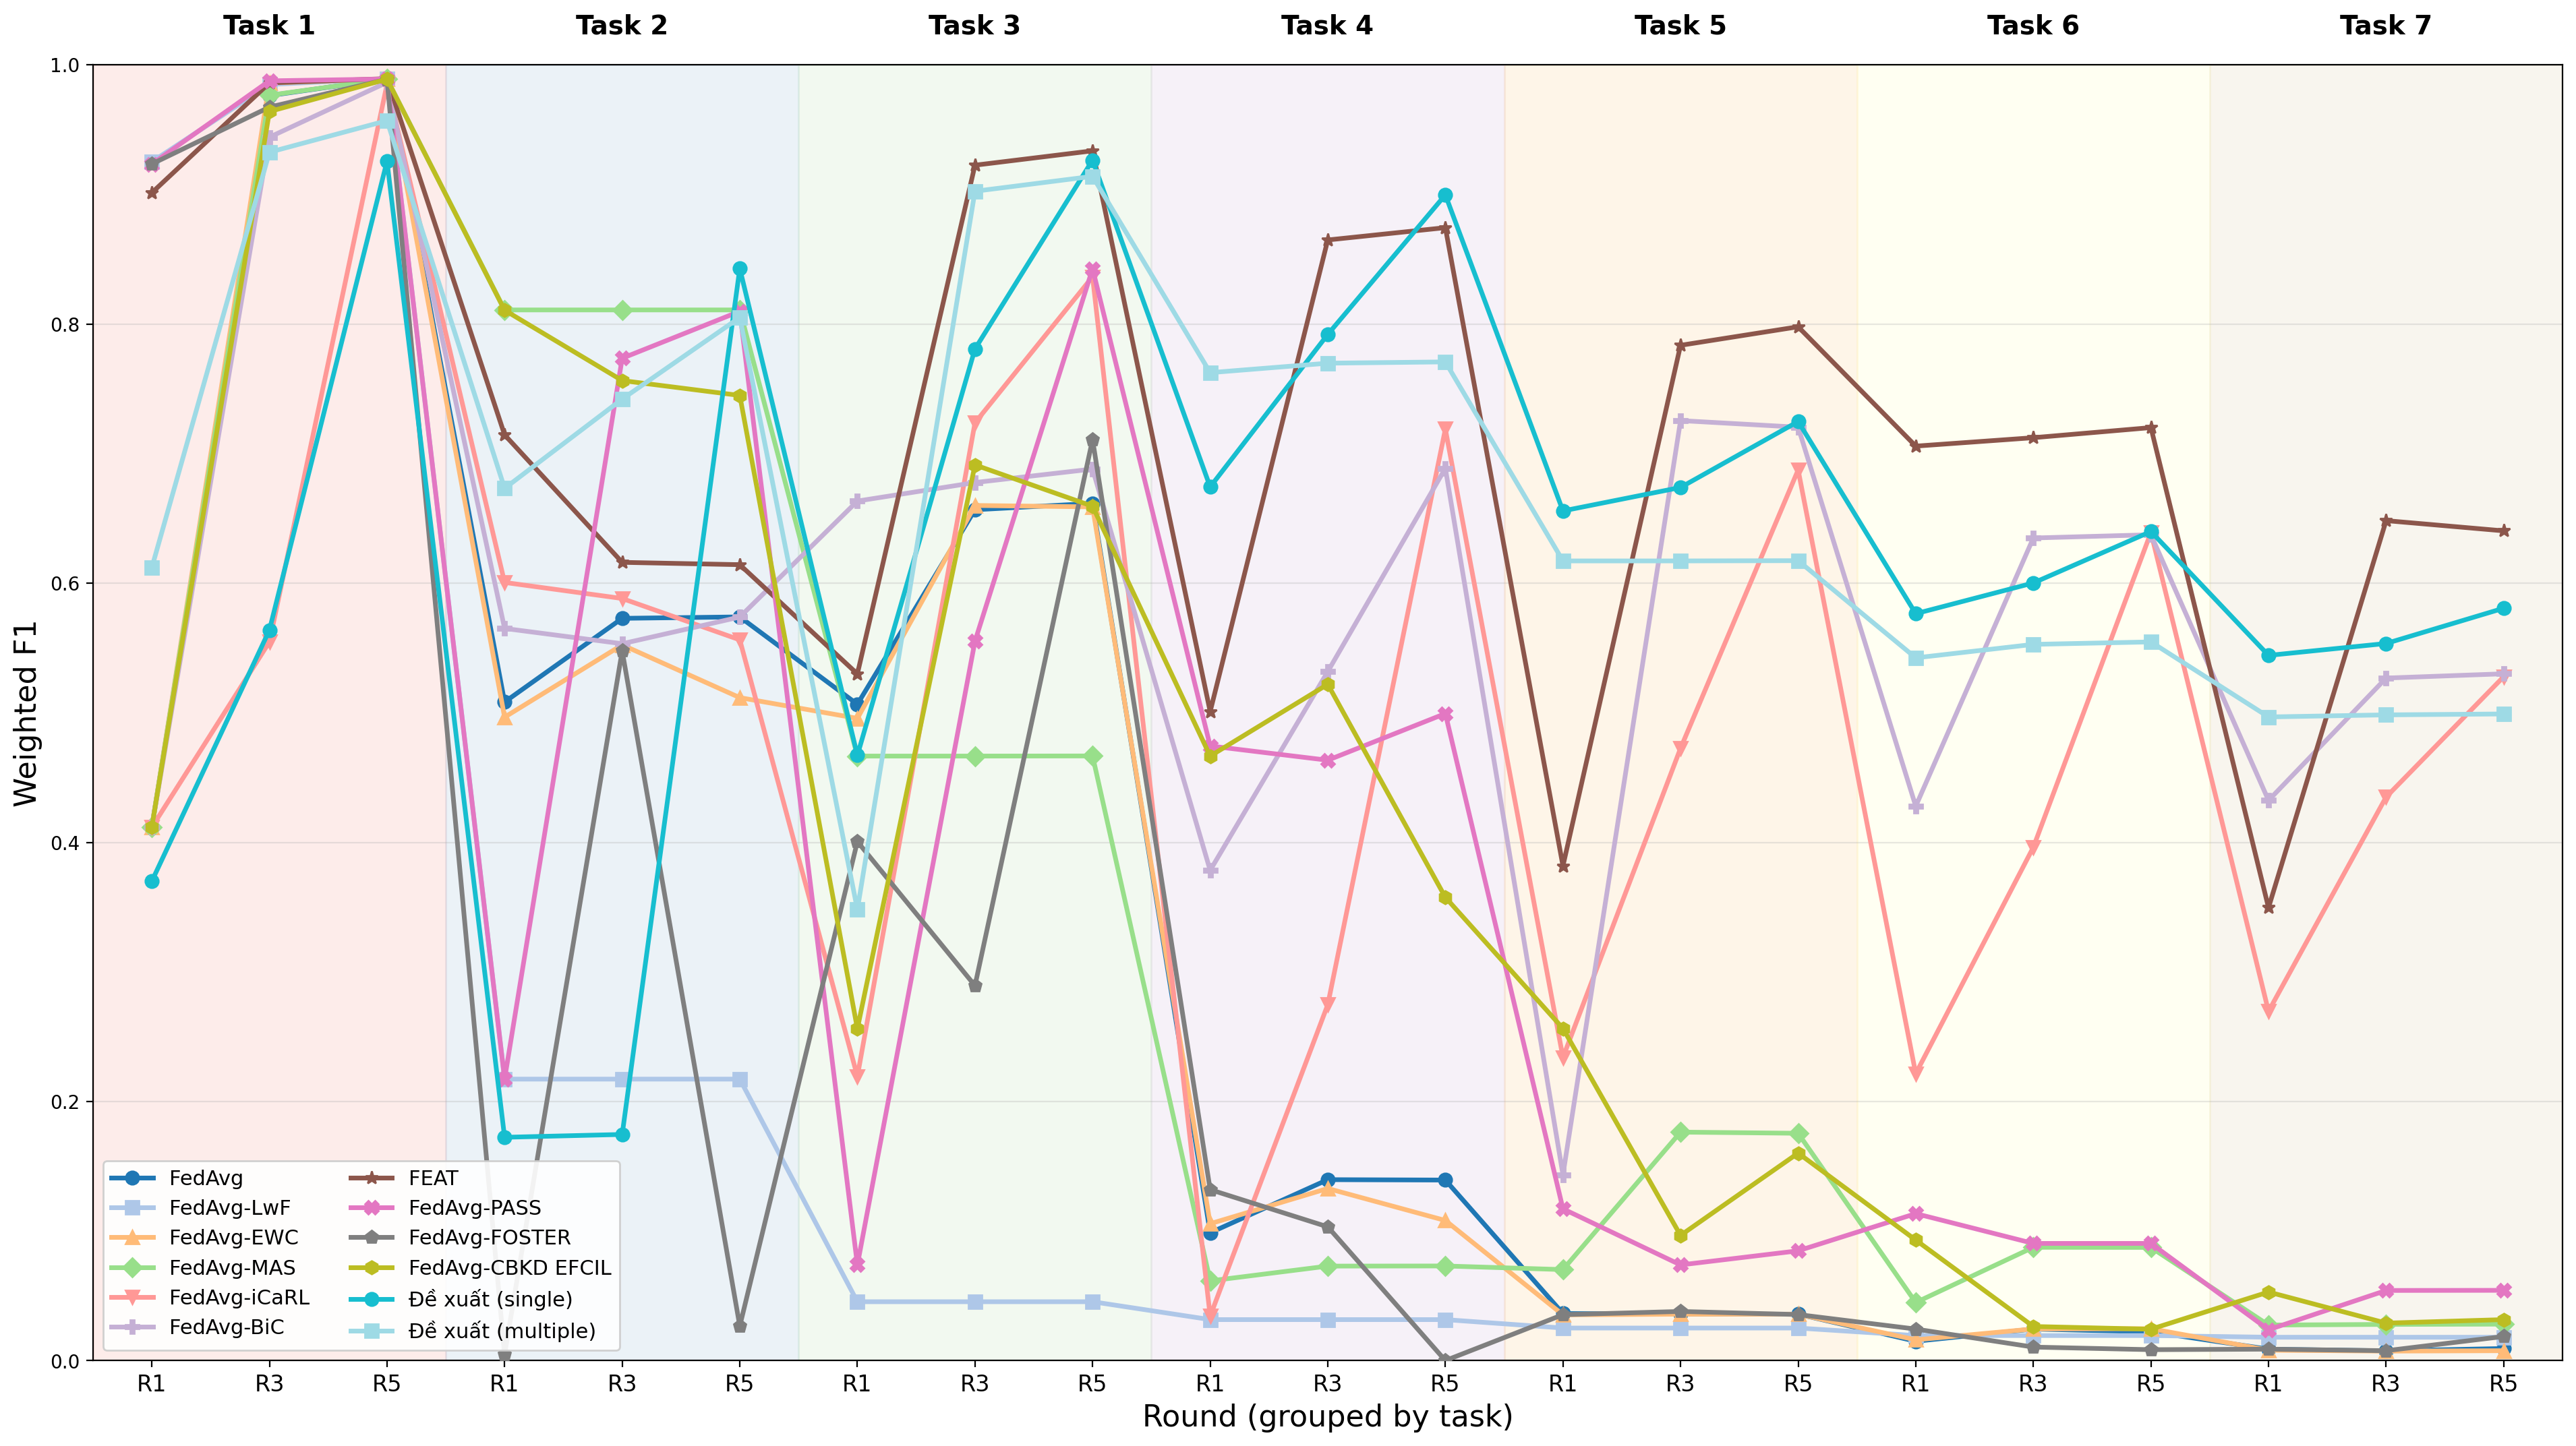

In [14]:
SHOW_ROUNDS = [1, 3, 5]
METRICS = [
    ("acc", "Accuracy"),
    ("f1_macro", "Macro F1"),
    ("f1_micro", "Micro F1"),
    ("f1_weighted", "Weighted F1"),
]
TASK_COLORS = plt.cm.Pastel1(np.linspace(0, 1, 9))
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'p', 'h']

parsed = []
for idx, path in enumerate(log_files):
    tasks, merged, task_max_round, offsets = parse_cil_log(path)
    label = canon_name[idx] if idx < len(canon_name) and canon_name[idx] else parse_name(path)
    parsed.append((label, merged, task_max_round))

all_tasks = sorted({t for _, _, tmr in parsed for t in tmr})

x_labels = []
x_keys = []
for t in all_tasks:
    for r in SHOW_ROUNDS:
        x_keys.append((t, r))
        x_labels.append(f"R{r}")
x_pos = np.arange(len(x_keys))

cand_colors = plt.cm.tab20(np.linspace(0, 1, max(len(parsed), 2)))

for key, title in METRICS:
    fig, ax = plt.subplots(1, 1, figsize=(19.2, 10.8), dpi=200)
    
    for t in all_tasks:
        cols = [i for i, (tt, _) in enumerate(x_keys) if tt == t]
        if cols:
            ax.axvspan(cols[0] - 0.5, cols[-1] + 0.5, color=TASK_COLORS[t % len(TASK_COLORS)], alpha=0.25, zorder=0)
            ax.text((cols[0] + cols[-1]) / 2, 1.02, f"Task {t + 1}", ha='center', va='bottom',
                    transform=ax.get_xaxis_transform(), fontsize=14, fontweight='bold')
    
    for idx, ((name, merged, tmr), color) in enumerate(zip(parsed, cand_colors)):
        ys = []
        for (t, r) in x_keys:
            vals = merged.get(t, {}).get(r)
            ys.append(vals[key] if vals else np.nan)
        ax.plot(x_pos, ys, marker=MARKERS[idx % len(MARKERS)], markersize=7, linewidth=2.5, color=color, label=name, zorder=3)
    
    ax.set_ylabel(title, fontsize=16)
    ax.set_ylim(0, 1)
    ax.grid(True, axis='y', alpha=0.3, zorder=1)
    ax.set_xlim(-0.5, len(x_keys) - 0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_xlabel("Round (grouped by task)", fontsize=16)
    ax.legend(ncol=2, fontsize=11, loc='lower left', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

## Part 2 — Per-task accuracy heatmap

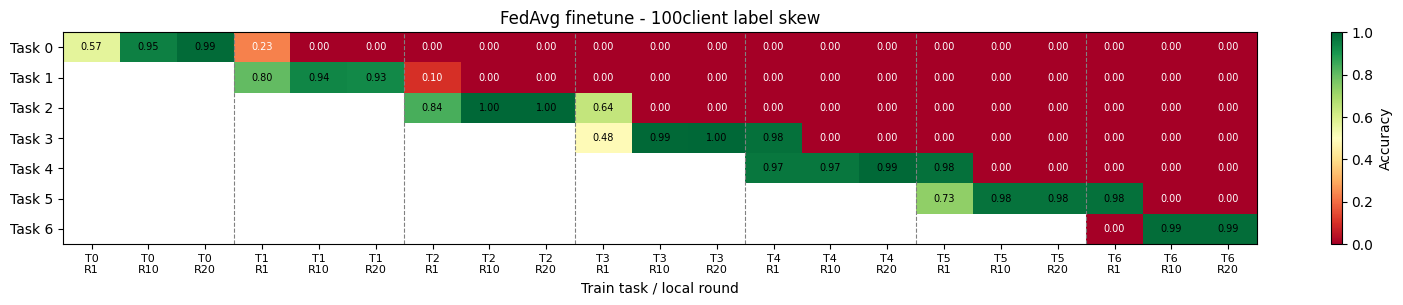

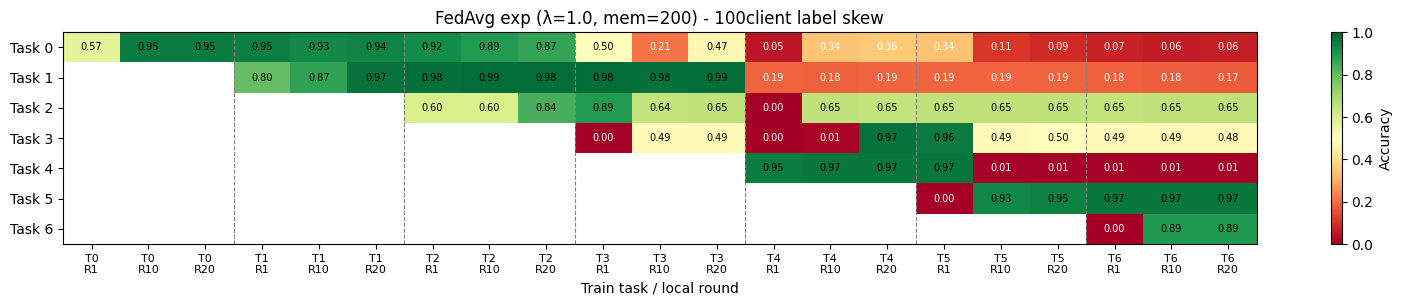

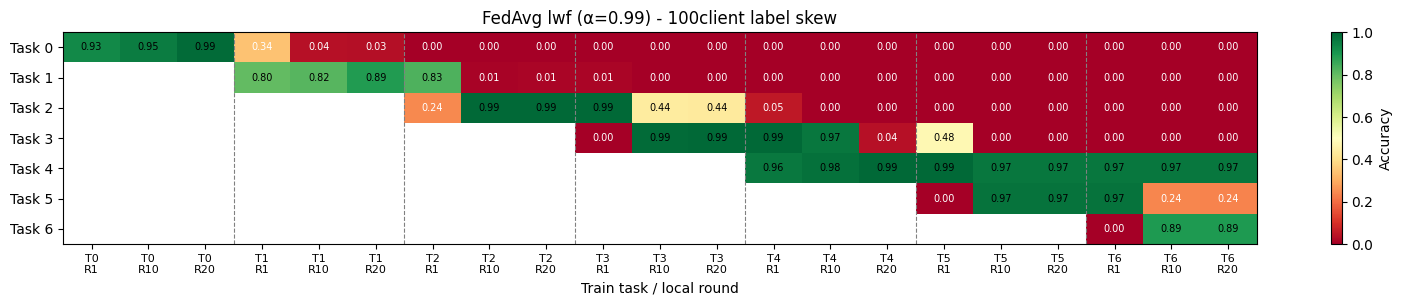

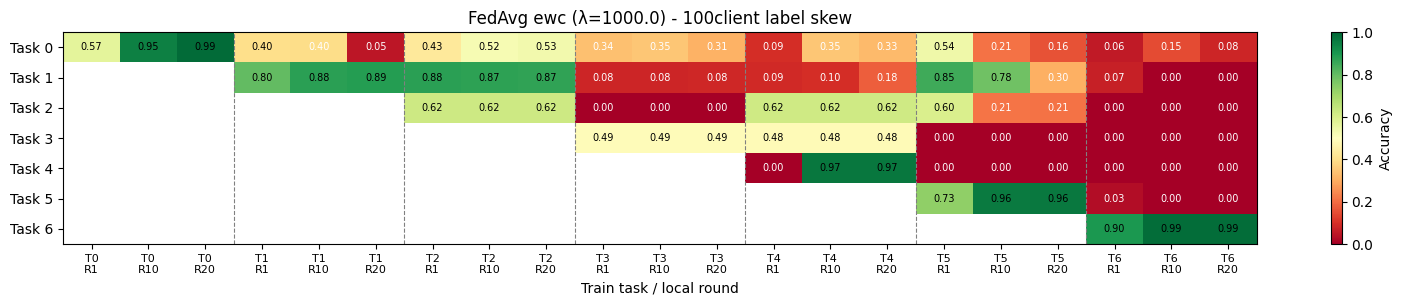

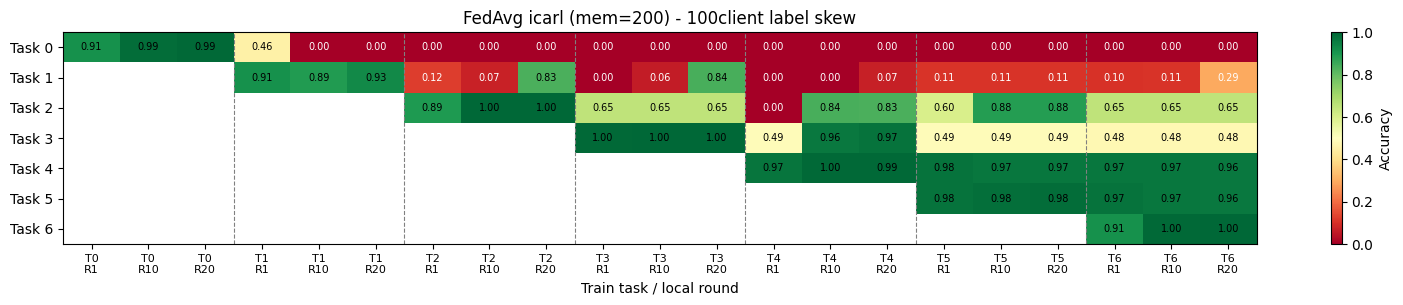

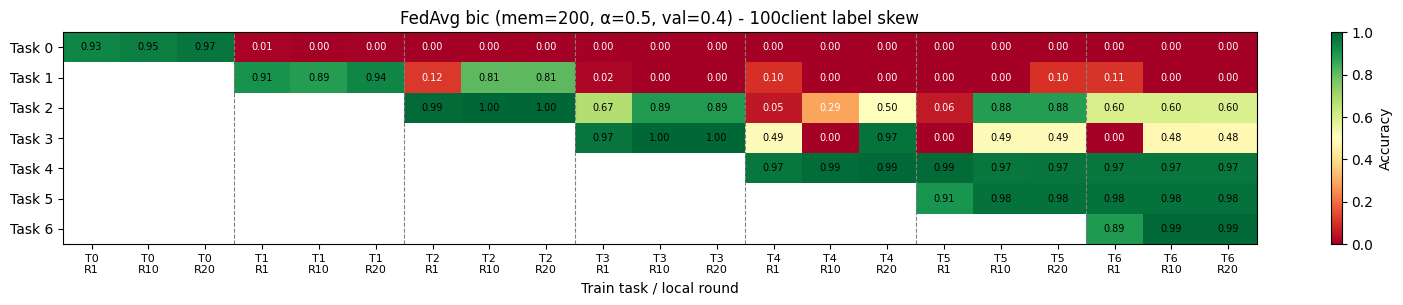

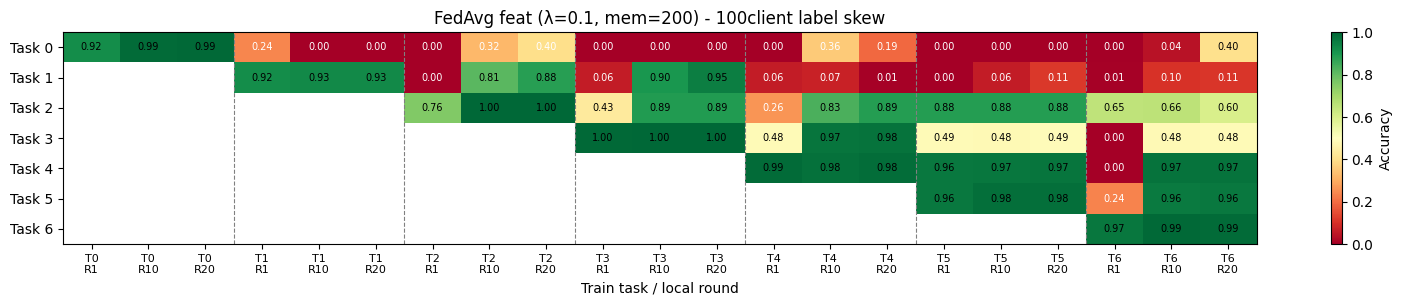

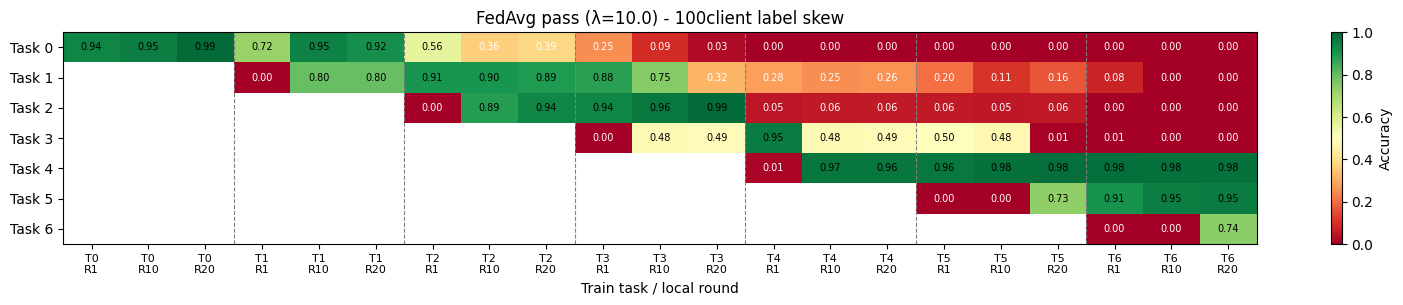

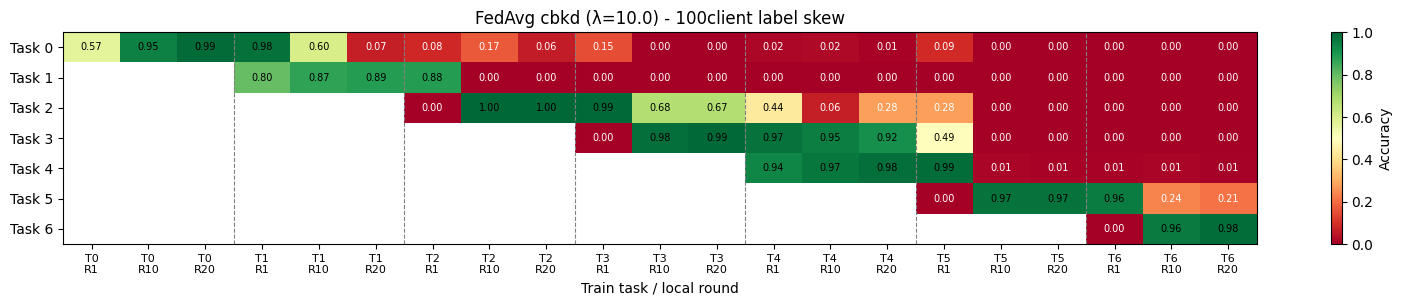

In [16]:
SHOW_LOCAL_ROUNDS = [1, 10, 20]

for path in log_files:
    tasks, merged, task_max_round, offsets = parse_cil_log(path)
    all_eval_tasks = sorted({et for t in tasks for r in tasks[t] for et in tasks[t][r]})
    columns = []
    labels = []
    for train_task in sorted(task_max_round):
        for r in SHOW_LOCAL_ROUNDS:
            if r <= task_max_round[train_task]:
                columns.append((train_task, r))
                labels.append(f"T{train_task}\nR{r}")
    grid = np.full((len(all_eval_tasks), len(columns)), np.nan)
    task_idx = {t: i for i, t in enumerate(all_eval_tasks)}
    for col, (train_task, r) in enumerate(columns):
        for et, vals in tasks.get(train_task, {}).get(r, {}).items():
            grid[task_idx[et], col] = vals["acc"]

    fig, ax = plt.subplots(figsize=(max(8, len(columns) * 0.75), max(3, len(all_eval_tasks) * 0.45)))
    im = ax.imshow(grid, aspect='auto', vmin=0, vmax=1, cmap='RdYlGn', interpolation='nearest')
    ax.set_yticks(range(len(all_eval_tasks)))
    ax.set_yticklabels([f"Task {t}" for t in all_eval_tasks])
    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel("Train task / local round")
    ax.set_title(parse_name(path))
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if not np.isnan(v):
                color = "white" if v < 0.4 else "black"
                ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7, color=color)
    for j in range(3, len(columns), 3):
        ax.axvline(j - 0.5, color='grey', linewidth=0.8, linestyle='--')
    fig.colorbar(im, ax=ax, label="Accuracy")
    plt.tight_layout()
    plt.show()


## Final metric comparison

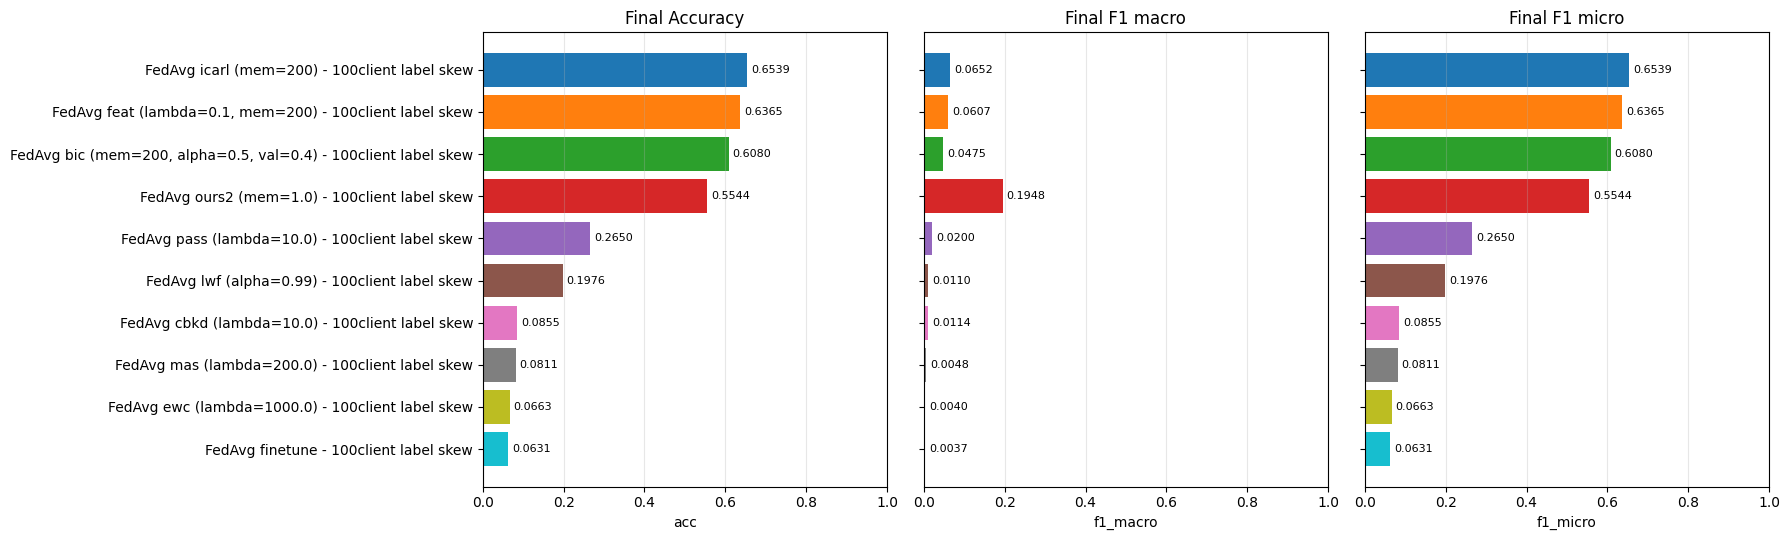

In [9]:
rows = []
for path in log_files:
    metrics = parse_final_metrics(path)
    if metrics is not None:
        rows.append((parse_name(path), metrics))

rows = sorted(rows, key=lambda x: x[1]["acc"], reverse=True)
names = [r[0] for r in rows]
metrics = [r[1] for r in rows]
plot_items = [("acc", "Final Accuracy"), ("f1_macro", "Final F1 macro"), ("f1_micro", "Final F1 micro")]

fig, axes = plt.subplots(1, 3, figsize=(18, max(3, len(names) * 0.55)), sharey=True)
if len(names) == 0:
    print("No final metrics found in selected logs.")
else:
    y = np.arange(len(names))
    for ax, (key, title) in zip(axes, plot_items):
        vals = [m.get(key, np.nan) for m in metrics]
        bars = ax.barh(y, vals, color=plt.cm.tab10(np.linspace(0, 1, len(names))))
        ax.set_title(title)
        ax.set_xlabel(key)
        ax.set_xlim(0, 1)
        ax.grid(True, axis='x', alpha=0.3)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.4f}", va='center', fontsize=8)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(names)
    axes[0].invert_yaxis()
    plt.tight_layout()
    plt.show()


## Final per-task accuracy comparison

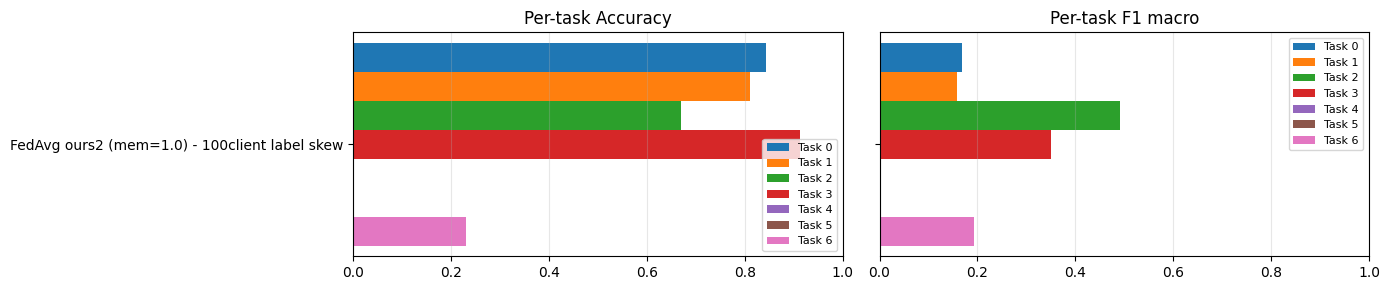

In [ ]:
per_task_re = re.compile(
    r"^(?:EVAL|FINAL)\s+\|\s+T(\d+)\s+\|\s+R(\d+)\s+\|\s+per-task\s+\|\s+(.*)"
)
task_entry_re = re.compile(r"T(\d+):acc=([\d.]+),f1=([\d.]+),n=(\d+)")


def parse_final_per_task(path):
    lines = Path(path).read_text().splitlines()
    last_per_task = None
    for raw in reversed(lines):
        line = ansi_re.sub("", raw).strip()
        line = timestamp_re.sub("", line)
        if line.startswith("FINAL") and "per-task" in line:
            last_per_task = line
            break
    if last_per_task is None:
        for raw in reversed(lines):
            line = ansi_re.sub("", raw).strip()
            line = timestamp_re.sub("", line)
            if "per-task" in line:
                last_per_task = line
                break
    if last_per_task is None:
        return {}
    parts = last_per_task.split("per-task |")[-1]
    result = {}
    for m in task_entry_re.finditer(parts):
        result[int(m.group(1))] = {"acc": float(m.group(2)), "f1_macro": float(m.group(3)), "support": int(m.group(4))}
    return result


all_per_task = {}
for path in log_files:
    pt = parse_final_per_task(path)
    if pt:
        all_per_task[parse_name(path)] = pt

if all_per_task:
    all_tasks = sorted({t for v in all_per_task.values() for t in v})
    fig, axes = plt.subplots(1, 2, figsize=(14, max(3, len(all_per_task) * 0.5)), sharey=True)
    y = np.arange(len(all_per_task))
    names_pt = list(all_per_task.keys())
    width = 0.8 / max(len(all_tasks), 1)
    for i, task_id in enumerate(all_tasks):
        accs = [all_per_task[n].get(task_id, {}).get("acc", 0.0) for n in names_pt]
        f1s = [all_per_task[n].get(task_id, {}).get("f1_macro", 0.0) for n in names_pt]
        axes[0].barh(y + i * width, accs, height=width, label=f"Task {task_id}")
        axes[1].barh(y + i * width, f1s, height=width, label=f"Task {task_id}")
    for ax, title in zip(axes, ["Per-task Accuracy", "Per-task F1 macro"]):
        ax.set_title(title)
        ax.set_xlim(0, 1)
        ax.grid(True, axis='x', alpha=0.3)
        ax.legend(fontsize=8)
    axes[0].set_yticks(y + width * (len(all_tasks) - 1) / 2)
    axes[0].set_yticklabels(names_pt)
    axes[0].invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No per-task breakdown found in logs (older format).")